# From Data to Final Model: A Complete Regression Machine-Learning Workflow

## Ames Housing: simple, multiple, and polynomial regression from data preparation to final testing

In this notebook we use one dataset to follow the **complete machine-learning model development cycle**.

The goal is to predict `SalePrice` for houses in the Ames Housing dataset. We will use simple, multiple, and polynomial linear regression as different approaches to solve the same prediction problem, and then compare their performance.

### The workflow

1. Define the prediction problem and evaluation metrics.
2. Load, clean, and explore the data.
3. Create **training, validation, and test sets once**.
4. Build a simple linear-regression baseline.
5. Explain direct least-squares optimization and gradient descent.
6. Build a multiple linear-regression model.
7. Engineer polynomial features using one variable and two variables.
8. Compare all candidate models on the **same validation set**.
9. Select the best model using validation RMSE.
10. Refit the selected model on training + validation data.
11. Use the untouched **test set once, at the very end**.
12. Discuss when feature scaling is necessary and when it is optional.

> **Important:** We do not use the test set for model selection. The test set represents new data that the model has not seen during development.


## Learning goals

By the end of the notebook, you should be able to explain:

- the difference between a **model** and an **optimization algorithm**;
- why ordinary least squares has a closed-form mathematical solution;
- how scikit-learn's `LinearRegression` solves the least-squares problem;
- how gradient descent minimizes mean squared error iteratively;
- why a fixed random seed is useful when comparing models;
- why categorical variables need preprocessing before linear regression;
- how polynomial features change model complexity;
- how training and validation results are used for model selection;
- why the test set should remain untouched until the final model has been selected;
- when feature scaling is necessary, useful, or optional.

In [11]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib_inline.backend_inline import set_matplotlib_formats

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

set_matplotlib_formats("svg")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 42


## 1. Define the prediction problem

Our **target variable** is:

- `SalePrice`: the house sale price.

We will begin with one predictor:

- `GrLivArea`: above-ground living area in square feet.

Later we will add more information:

**Numerical variables**
- `GrLivArea`
- `OverallQual`
- `YearBuilt`
- `GarageCars`
- `TotalBsmtSF`

**Categorical variables**
- `Neighborhood`
- `HouseStyle`
- `KitchenQual`

We will compare models using three regression metrics:

- **MAE**: mean absolute error. Easy to interpret because it is in the same unit as the target.
- **RMSE**: root mean squared error. Large errors receive more weight, so we will use this as the **main model-selection metric**.
- **R²**: proportion of variation explained by the model. Higher is generally better, but it should not be used alone.

In [12]:
ames = fetch_openml(
    data_id=42165,
    as_frame=True,
    parser="auto"
)

housing = ames.frame.copy()

print("Dataset shape:", housing.shape)
housing.head()

Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Prepare one common modeling dataset

To compare models fairly, all candidates should use the **same observations** and the **same train/validation/test split**.

Some models will use only one or two predictors, while others will use all selected predictors. We therefore create one table containing every feature that may be needed.

For this notebook, we **do not impute missing values**. Instead, we remove rows that have a missing value in any selected predictor or in `SalePrice`. We also report how many observations are removed and how many remain.


In [ ]:
numeric_features = [
    "GrLivArea",
    "OverallQual",
    "YearBuilt",
    "GarageCars",
    "TotalBsmtSF"
]

categorical_features = [
    "Neighborhood",
    "HouseStyle",
    "KitchenQual"
]

all_features = numeric_features + categorical_features

# Keep only the variables that will be used in this notebook.
data = housing[all_features + ["SalePrice"]].copy()

# Report missing-value removal.
n_before = len(data)
data = data.dropna(subset=all_features + ["SalePrice"])
n_after = len(data)
n_removed = n_before - n_after

# Make sure the target is numeric.
data["SalePrice"] = data["SalePrice"].astype(float)

X = data[all_features]
y = data["SalePrice"]

print(f"Observations before removing missing values: {n_before}")
print(f"Observations removed: {n_removed}")
print(f"Observations remaining: {n_after}")
print(f"Percentage retained: {100 * n_after / n_before:.1f}%")
print(f"Shape of X: {X.shape}")

X.head()


## 3. Explore the data before modeling

Before fitting a model, we should understand the variables we plan to use and how they relate to the target variable, `SalePrice`.

- For **numerical variables**, scatter plots help us see relationships, possible trends, and unusual observations.
- For **categorical variables**, box plots help us compare the distribution of sale prices across categories.

Exploration is not the same as model evaluation. At this stage, we are trying to understand the data and develop reasonable modeling ideas.


In [ ]:
# Explore numerical predictors against sale price in one figure.
fig, axes = plt.subplots(1, len(numeric_features), figsize=(5 * len(numeric_features), 4))
axes = np.atleast_1d(axes)

for ax, feature in zip(axes, numeric_features):
    ax.scatter(X[feature], y, alpha=0.35)
    ax.set_xlabel(feature)
    ax.set_ylabel("Sale price")
    ax.set_title(f"Sale price vs. {feature}")

plt.tight_layout()
plt.show()


In [ ]:
# Explore categorical predictors against sale price in one figure.
fig, axes = plt.subplots(1, len(categorical_features), figsize=(7 * len(categorical_features), 5))
axes = np.atleast_1d(axes)

for ax, feature in zip(axes, categorical_features):
    categories = X[feature].dropna().unique()
    grouped_prices = [y[X[feature] == category] for category in categories]

    ax.boxplot(grouped_prices, tick_labels=categories)
    ax.set_xlabel(feature)
    ax.set_ylabel("Sale price")
    ax.set_title(f"Sale price by {feature}")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 4. Create training, validation, and test sets — once

We split the data **before model selection** and reuse exactly the same split for every candidate.

- **Training set:** used to fit model parameters.
- **Validation set:** used to compare models and make modeling decisions.
- **Test set:** kept untouched until the final model has been selected.

We first reserve 20% for testing. We then take 25% of the remaining 80% for validation. This gives approximately:

- 60% training
- 20% validation
- 20% test

### Why use `random_state=42`?

`train_test_split` randomly assigns rows to subsets. Setting a fixed random seed makes the assignment reproducible. If we rerun the notebook, or compare a new model next week, we can use the **same observations in the same subsets**.

This matters because otherwise a change in performance could come from a different random split rather than from a better or worse model.

The number 42 has no statistical magic; it is simply a fixed seed.

In [14]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.25,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 876
Validation samples: 292
Test samples: 292


## 5. A reusable evaluation function

We will use the same metrics for every model so that comparisons are consistent.

RMSE will be the primary model-selection metric. The function below returns all three metrics for a fitted model and a chosen dataset.

In [15]:
def regression_metrics(model, X_part, y_part):
    predictions = model.predict(X_part)

    return pd.Series({
        "MAE": mean_absolute_error(y_part, predictions),
        "RMSE": mean_squared_error(y_part, predictions) ** 0.5,
        "R2": r2_score(y_part, predictions)
    })

# Part I — Simple Linear Regression

## 6. Build a simple linear-regression baseline

We begin with only `GrLivArea` as a predictor. This gives us a simple baseline that is easy to interpret and visualize.


In [8]:
simple_model = LinearRegression()

start = time.perf_counter()
simple_model.fit(X_train[["GrLivArea"]], y_train)
ols_fit_time = time.perf_counter() - start

simple_results = pd.DataFrame({
    "Train": regression_metrics(
        simple_model, X_train[["GrLivArea"]], y_train
    ),
    "Validation": regression_metrics(
        simple_model, X_val[["GrLivArea"]], y_val
    )
}).T

print(f"scikit-learn fit time: {ols_fit_time:.6f} seconds")
simple_results

scikit-learn fit time: 0.118160 seconds


,MAE,RMSE,R2
Train,37680.885607,56288.411209,0.468072
Validation,36136.865650,53090.634009,0.529322


In [23]:
reg = simple_model

print("Intercept:", reg.intercept_)
print("Coefficient for GrLivArea:", reg.coef_[0])

Intercept: 28700.96819764137
Coefficient for GrLivArea: 99.55534848670175


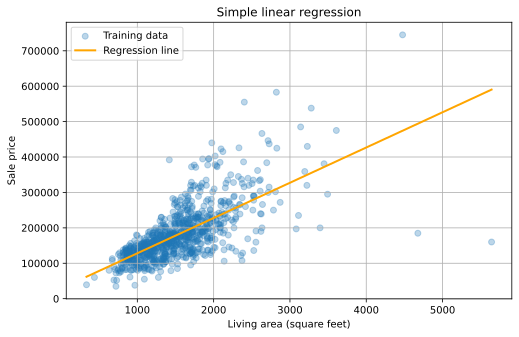

In [9]:
x_line = np.linspace(
    X_train["GrLivArea"].min(),
    X_train["GrLivArea"].max(),
    200
)

x_line_df = pd.DataFrame({"GrLivArea": x_line})
y_line = simple_model.predict(x_line_df)

plt.scatter(
    X_train["GrLivArea"],
    y_train,
    alpha=0.30,
    label="Training data"
)
plt.plot(x_line, y_line, linewidth=2, label="Regression line", color="orange")
plt.xlabel("Living area (square feet)")
plt.ylabel("Sale price")
plt.title("Simple linear regression")
plt.legend()
plt.show()

### What does `LinearRegression` optimize?

Linear regression chooses the coefficients that minimize the **sum of squared errors** between the observed and predicted values:

$$
J(\mathbf{w}) = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

There are two common ways to find the coefficients that minimize this error:

1. **Direct mathematical solution**  
   Ordinary least squares can be solved directly using linear algebra:

$$
\mathbf{w}=(X^T X)^{-1}X^T\mathbf{y}
$$

when $X^TX$ is invertible.

2. **Gradient descent**  
   We can also start with initial coefficient values and improve them iteratively. During training, gradient descent repeatedly updates the coefficients in the direction that reduces the error.

`scikit-learn`'s `LinearRegression` uses a **direct least-squares solution**, rather than a gradient-descent training loop. In practice, it uses numerically stable least-squares routines rather than explicitly calculating the matrix inverse.

Gradient descent can be useful when datasets are very large, when an iterative or mini-batch optimization approach is preferred, or for models that do not have a convenient direct solution.


### Inspect residuals for the simple model

A residual is

$$
\text{residual} = y - \hat{y}
$$

Residual plots help us look for systematic patterns that the model has failed to capture. Ideally, residuals should be scattered around zero without a strong structure.


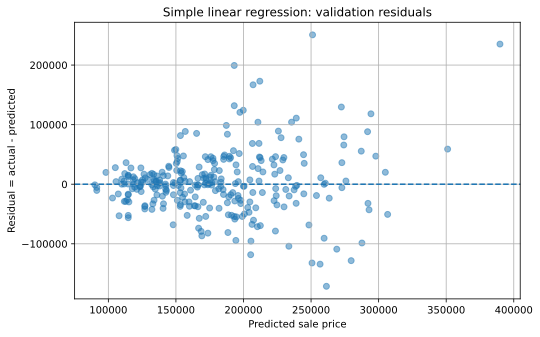

In [10]:
simple_val_pred = simple_model.predict(X_val[["GrLivArea"]])
simple_residuals = y_val - simple_val_pred

plt.scatter(simple_val_pred, simple_residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted sale price")
plt.ylabel("Residual = actual - predicted")
plt.title("Simple linear regression: validation residuals")
plt.show()

# Part II — Multiple Linear Regression

## 7. Add more predictors

Living area contains useful information, but house prices depend on more than one variable.

A multiple linear-regression model has the form

$$
\hat{y} = b_0 + b_1x_1 + b_2x_2 + \cdots + b_px_p
$$

Adding relevant predictors can reduce prediction error, but adding variables does **not automatically guarantee better generalization**. That is why we evaluate the new model on the validation set.


### Prepare numerical and categorical variables

`LinearRegression` requires numerical input. The numerical predictors can be used directly, while categorical predictors are converted to numerical columns with **one-hot encoding**.

The encoder is fitted **only on the training data** and then used to transform the validation data. This avoids information from the validation set leaking into model training.

There is no imputation and no feature scaling in this step.


In [ ]:
# Fit the one-hot encoder only on the training data.
onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
onehot.fit(X_train[categorical_features])

# Transform categorical predictors.
X_train_cat = onehot.transform(X_train[categorical_features])
X_val_cat = onehot.transform(X_val[categorical_features])

# Keep numerical predictors in their original units.
X_train_num = X_train[numeric_features].to_numpy()
X_val_num = X_val[numeric_features].to_numpy()

# Combine numerical and encoded categorical predictors.
X_train_multiple = np.column_stack([X_train_num, X_train_cat])
X_val_multiple = np.column_stack([X_val_num, X_val_cat])

# Train the multiple linear regression model using all prepared predictors.
multiple_model = LinearRegression()
multiple_model.fit(X_train_multiple, y_train)

# Evaluate the model on the training and validation sets.
multiple_train_pred = multiple_model.predict(X_train_multiple)
multiple_val_pred = multiple_model.predict(X_val_multiple)

multiple_results = pd.DataFrame({
    "Train": {
        "MAE": mean_absolute_error(y_train, multiple_train_pred),
        "RMSE": mean_squared_error(y_train, multiple_train_pred) ** 0.5,
        "R2": r2_score(y_train, multiple_train_pred)
    },
    "Validation": {
        "MAE": mean_absolute_error(y_val, multiple_val_pred),
        "RMSE": mean_squared_error(y_val, multiple_val_pred) ** 0.5,
        "R2": r2_score(y_val, multiple_val_pred)
    }
}).T

multiple_results


## 12. Predicted versus actual values

If predictions were perfect, every point would lie on the diagonal line where

$$\text{predicted} = \text{actual}$$

The plot below gives a visual summary of validation performance.

In [ ]:
plt.scatter(
    y_val,
    multiple_val_pred,
    alpha=0.5,
    label="Predictions"
)

low = min(y_val.min(), multiple_val_pred.min())
high = max(y_val.max(), multiple_val_pred.max())

plt.plot(
    [low, high],
    [low, high],
    linestyle="--",
    color="red",
    label="Perfect predictions"
)

plt.xlabel("Actual sale price")
plt.ylabel("Predicted sale price")
plt.title("Multiple linear regression: validation predictions")
plt.legend()
plt.show()


# Part III — Polynomial Regression and Feature Engineering

## 8. What if the relationship is curved?

So far, linear regression has used the original predictors directly.

However, the relationship between a predictor and the target does not always have to be a straight line. We can create **new features** from existing variables and give these transformed features to the linear regression model. This process is called **feature engineering**.

For example, starting from a numerical variable $x$, we could create:

- $x^2$
- $x^3$
- $\log(x)$
- $\sqrt{x}$

Polynomial transformations are one type of feature engineering. A degree-2 polynomial model based on one variable uses:

$$
x,\;x^2
$$

and has the form

$$
\hat{y}=b_0+b_1x+b_2x^2
$$

Although the relationship with $x$ is curved, this is still a **linear regression model**, because the model is linear in the coefficients.

With two numerical variables, degree-2 polynomial features can also create an **interaction term**:

$$
x_1,\;x_2,\;x_1^2,\;x_1x_2,\;x_2^2
$$

The term $x_1x_2$ allows the effect of one variable to depend on the value of the other.


In [ ]:
# Example 1: polynomial regression with ONE numerical variable.
poly_one_features = ["GrLivArea"]
poly_one = PolynomialFeatures(degree=2, include_bias=False)

# Fit the feature transformation only on training data.
poly_one.fit(X_train[poly_one_features])
X_train_poly_one = poly_one.transform(X_train[poly_one_features])
X_val_poly_one = poly_one.transform(X_val[poly_one_features])

print("Original feature:")
for feature in poly_one_features:
    print(f"  - {feature}")

print("Engineered feature:")
for feature in poly_one.get_feature_names_out(poly_one_features):
    if feature not in poly_one_features:
        print(f"  - {feature}")

# Train and evaluate the one-variable polynomial model.
poly_one_model = LinearRegression()
poly_one_model.fit(X_train_poly_one, y_train)

poly_one_train_pred = poly_one_model.predict(X_train_poly_one)
poly_one_val_pred = poly_one_model.predict(X_val_poly_one)

poly_one_results = pd.DataFrame({
    "Train": {
        "MAE": mean_absolute_error(y_train, poly_one_train_pred),
        "RMSE": mean_squared_error(y_train, poly_one_train_pred) ** 0.5,
        "R2": r2_score(y_train, poly_one_train_pred)
    },
    "Validation": {
        "MAE": mean_absolute_error(y_val, poly_one_val_pred),
        "RMSE": mean_squared_error(y_val, poly_one_val_pred) ** 0.5,
        "R2": r2_score(y_val, poly_one_val_pred)
    }
}).T

print("\nOne-Variable Polynomial Regression Results:")
print(poly_one_results)

In [ ]:
# Visualize the one-variable degree-2 polynomial model.
x_grid = np.linspace(
    X_train["GrLivArea"].min(),
    X_train["GrLivArea"].max(),
    400
).reshape(-1, 1)

x_grid_poly = poly_one.transform(x_grid)
y_grid = poly_one_model.predict(x_grid_poly)

plt.scatter(X_train["GrLivArea"], y_train, alpha=0.20, label="Training data")
plt.plot(x_grid.ravel(), y_grid, color="red", linewidth=2, label="Degree-2 polynomial")
plt.xlabel("Living area (square feet)")
plt.ylabel("Sale price")
plt.title("Polynomial regression with one numerical variable")
plt.legend()
plt.show()


In [ ]:
# Example 2: polynomial regression with TWO numerical variables.
poly_two_features = ["GrLivArea", "OverallQual"]
poly_two = PolynomialFeatures(degree=2, include_bias=False)

# Fit the feature transformation only on training data.
poly_two.fit(X_train[poly_two_features])
X_train_poly_two = poly_two.transform(X_train[poly_two_features])
X_val_poly_two = poly_two.transform(X_val[poly_two_features])

all_poly_two_features = poly_two.get_feature_names_out(poly_two_features)

print("Original features:")
for feature in poly_two_features:
    print(f"  - {feature}")

print("Engineered features:")
for feature in all_poly_two_features:
    if feature not in poly_two_features:
        print(f"  - {feature}")

# Train and evaluate the two-variable polynomial model.
poly_two_model = LinearRegression()
poly_two_model.fit(X_train_poly_two, y_train)

poly_two_train_pred = poly_two_model.predict(X_train_poly_two)
poly_two_val_pred = poly_two_model.predict(X_val_poly_two)

poly_two_results = pd.DataFrame({
    "Train": {
        "MAE": mean_absolute_error(y_train, poly_two_train_pred),
        "RMSE": mean_squared_error(y_train, poly_two_train_pred) ** 0.5,
        "R2": r2_score(y_train, poly_two_train_pred)
    },
    "Validation": {
        "MAE": mean_absolute_error(y_val, poly_two_val_pred),
        "RMSE": mean_squared_error(y_val, poly_two_val_pred) ** 0.5,
        "R2": r2_score(y_val, poly_two_val_pred)
    }
}).T

poly_two_results


# Part IV — Model Comparison and Selection

## 9. Compare all candidate models on the validation set

This is the model-selection stage. We compare models only on the **validation set**, using the same validation observations for every candidate.

We compare:

- simple linear regression using `GrLivArea`;
- multiple linear regression using all selected numerical and categorical predictors;
- degree-2 polynomial regression using **one numerical variable**, `GrLivArea`;
- degree-2 polynomial regression using **two numerical variables**, `GrLivArea` and `OverallQual`.

The one-variable and two-variable polynomial examples are therefore not just demonstrations: **both are candidate models** in the final comparison.

We use **validation RMSE** as the main model-selection metric. The test set is still untouched.


In [ ]:
candidate_rows = []

# Simple linear regression.
simple_val_pred = simple_model.predict(X_val[["GrLivArea"]])
candidate_rows.append({
    "Model": "Simple linear",
    "MAE": mean_absolute_error(y_val, simple_val_pred),
    "RMSE": mean_squared_error(y_val, simple_val_pred) ** 0.5,
    "R2": r2_score(y_val, simple_val_pred)
})

# Multiple linear regression.
candidate_rows.append({
    "Model": "Multiple linear",
    "MAE": mean_absolute_error(y_val, multiple_val_pred),
    "RMSE": mean_squared_error(y_val, multiple_val_pred) ** 0.5,
    "R2": r2_score(y_val, multiple_val_pred)
})

# Polynomial regression with one variable.
candidate_rows.append({
    "Model": "Polynomial degree 2 — one variable",
    "MAE": mean_absolute_error(y_val, poly_one_val_pred),
    "RMSE": mean_squared_error(y_val, poly_one_val_pred) ** 0.5,
    "R2": r2_score(y_val, poly_one_val_pred)
})

# Polynomial regression with two variables.
candidate_rows.append({
    "Model": "Polynomial degree 2 — two variables",
    "MAE": mean_absolute_error(y_val, poly_two_val_pred),
    "RMSE": mean_squared_error(y_val, poly_two_val_pred) ** 0.5,
    "R2": r2_score(y_val, poly_two_val_pred)
})

model_comparison = (
    pd.DataFrame(candidate_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

model_comparison


# Part V — Select, Refit, and Test the Final Model

## 10. Choose the best model and evaluate it on the test set

We select the candidate with the **lowest validation RMSE**.

The test set has not been used to make this choice. This is important because repeatedly checking test performance during model development would make the test set part of the selection process.

After selecting the model type, we refit that model using the combined **training + validation** development data. Only then do we evaluate it once on the untouched test set.


In [ ]:
best_model_name = model_comparison.loc[0, "Model"]

print("Selected model:", best_model_name)
print(f"Validation RMSE: {model_comparison.loc[0, 'RMSE']:.2f}")


## 11. Refit the selected model on training + validation data

The exact preprocessing must be refitted on the larger development set. The code below handles each candidate explicitly so students can see what happens for simple, multiple, and polynomial regression.


In [ ]:
# Refit the selected model on the full development set and prepare the test set.
if best_model_name == "Simple linear":
    final_model = LinearRegression()
    final_model.fit(X_trainval[["GrLivArea"]], y_trainval)
    X_test_final = X_test[["GrLivArea"]]

elif best_model_name == "Multiple linear":
    final_onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    final_onehot.fit(X_trainval[categorical_features])

    X_trainval_cat = final_onehot.transform(X_trainval[categorical_features])
    X_test_cat = final_onehot.transform(X_test[categorical_features])

    X_trainval_num = X_trainval[numeric_features].to_numpy()
    X_test_num = X_test[numeric_features].to_numpy()

    X_trainval_final = np.column_stack([X_trainval_num, X_trainval_cat])
    X_test_final = np.column_stack([X_test_num, X_test_cat])

    final_model = LinearRegression()
    final_model.fit(X_trainval_final, y_trainval)

elif best_model_name == "Polynomial degree 2 — one variable":
    final_poly = PolynomialFeatures(degree=2, include_bias=False)
    final_poly.fit(X_trainval[poly_one_features])

    X_trainval_final = final_poly.transform(X_trainval[poly_one_features])
    X_test_final = final_poly.transform(X_test[poly_one_features])

    final_model = LinearRegression()
    final_model.fit(X_trainval_final, y_trainval)

elif best_model_name == "Polynomial degree 2 — two variables":
    final_poly = PolynomialFeatures(degree=2, include_bias=False)
    final_poly.fit(X_trainval[poly_two_features])

    X_trainval_final = final_poly.transform(X_trainval[poly_two_features])
    X_test_final = final_poly.transform(X_test[poly_two_features])

    final_model = LinearRegression()
    final_model.fit(X_trainval_final, y_trainval)

# Evaluate the selected model once on the untouched test set.
test_predictions = final_model.predict(X_test_final)

final_test_metrics = pd.Series({
    "MAE": mean_absolute_error(y_test, test_predictions),
    "RMSE": mean_squared_error(y_test, test_predictions) ** 0.5,
    "R2": r2_score(y_test, test_predictions)
}, name="Test performance")

print("Final selected model:", best_model_name)
final_test_metrics


## 13. Visualize final test predictions

This plot is **not** used to choose a model. The model has already been selected using validation data. It is a final diagnostic view of predictions on previously untouched observations.


In [ ]:
plt.scatter(y_test, test_predictions, alpha=0.5, label="Predictions")

low = min(y_test.min(), test_predictions.min())
high = max(y_test.max(), test_predictions.max())

plt.plot(
    [low, high],
    [low, high],
    linestyle="--",
    color="red",
    label="Perfect predictions"
)

plt.xlabel("Actual sale price")
plt.ylabel("Predicted sale price")
plt.title(f"Final test set: {best_model_name}")
plt.legend()
plt.show()


# Summary: the complete regression ML cycle

In this notebook we followed one continuous ML workflow.

1. We defined a prediction problem and evaluation metrics.
2. We removed incomplete observations and reported how much data remained.
3. We explored numerical and categorical predictors.
4. We created one reproducible training/validation/test split.
5. We built a simple linear-regression baseline.
6. We connected least squares to direct optimization and gradient descent.
7. We built a multiple linear-regression model with explicit one-hot encoding.
8. We used feature engineering to build **one-variable and two-variable polynomial regression models**.
9. We compared all candidate models using validation RMSE.
10. We selected the best candidate without looking at test performance.
11. We refit the selected model on training + validation data.
12. We evaluated it once on the untouched test set.
13. We discussed when feature scaling is optional and when it becomes important.

The central workflow is: **develop on training data, choose with validation data, and estimate final generalization with test data.**


## Questions for students

1. What is the difference between a regression model and the algorithm used to optimize its coefficients?
2. Why can ordinary least squares be solved without a gradient-descent training loop?
3. Why do all candidate models use the same train/validation/test split?
4. Why must the one-hot encoder be fitted only on development data?
5. Why can a polynomial regression model still be fitted with `LinearRegression`?
6. What new feature is created when one variable is expanded to degree 2?
7. What additional interaction term appears when two variables are expanded to degree 2?
8. Why can the two-variable polynomial model behave differently from the one-variable polynomial model?
9. Why is the model with the lowest training RMSE not necessarily the best model?
10. Why is validation RMSE used for model selection rather than test RMSE?
11. Why do we refit the selected model on training + validation data before final testing?
12. Why is feature scaling optional for unregularized ordinary least squares but often important for gradient descent or regularized models?


<details>
<summary><strong>Appendix: Batch Gradient Descent for Simple Linear Regression</strong></summary>

Gradient descent repeatedly updates the intercept and slope in the direction that reduces mean squared error. This optional reference uses separate learning rates because the raw living-area feature and the intercept have very different numerical scales.

$$\hat{y}_i = b_0 + b_1 x_i$$

$$J(b_0, b_1) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

```python
def fit_simple_linear_gd(
    x,
    y,
    learning_rate_intercept=0.05,
    learning_rate_slope=1e-8,
    max_iter=200_000,
    tolerance=1e-8
):
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()
    b0, b1 = 0.0, 0.0
    previous_loss = np.inf
    history = []

    for iteration in range(max_iter):
        predictions = b0 + b1 * x
        errors = predictions - y
        loss = np.mean(errors ** 2)
        b0 -= learning_rate_intercept * 2.0 * np.mean(errors)
        b1 -= learning_rate_slope * 2.0 * np.mean(errors * x)

        if iteration % 1000 == 0:
            history.append((iteration, loss))
        if abs(previous_loss - loss) / max(previous_loss, 1.0) < tolerance:
            break
        previous_loss = loss

    return {
        "intercept": b0,
        "slope": b1,
        "iterations": iteration + 1,
        "history": pd.DataFrame(history, columns=["iteration", "MSE"])
    }

x_train_simple = X_train["GrLivArea"].astype(float).to_numpy()
y_train_array = y_train.to_numpy(dtype=float)
gd_solution = fit_simple_linear_gd(x_train_simple, y_train_array)
gd_solution
```

</details>

# Part VI — Do We Need Feature Scaling Here?

## Feature scaling: necessary or optional?

For **unregularized ordinary least-squares `LinearRegression`**, feature scaling is generally **optional**. Changing the units of a predictor changes its coefficient, but the model can still represent the same predictions.

However, scaling becomes important in other situations:

- **Gradient descent / SGD:** scaling is often strongly recommended because predictors with very different magnitudes can make optimization slow or unstable.
- **Regularized linear models such as Ridge and Lasso:** scaling is normally important so that the penalty treats predictors fairly.
- **Distance-based methods:** scaling is often essential because distances depend directly on feature magnitude.

So feature scaling is not a step that must always be applied. Its importance depends on the **model, optimizer, and objective function**.
